# Adiantando a saida

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carrega e prepara os dados
data = pd.read_csv("../DataSpline.csv")
data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data["theta"] = data["theta(Wd,We)"]
data["theta(Wd,We)"] = data["theta(Wd,We)"].shift(1)

data = data.iloc[1:]

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

PREDICTORS = ["Wd", "We"]
TARGET = ["theta(Wd,We)", "theta"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Paletas manuais para preditores e alvos
    predictor_colors = plt.cm.tab10.colors
    target_colors = plt.cm.Set2.colors

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot preditores no eixo esquerdo
    for i, preds in enumerate(PREDICTORS):
        ax1.plot(df.index, df[preds], marker="o", label=preds,
                 color=predictor_colors[i % len(predictor_colors)],
                 linewidth=2)

    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")
    ax1.tick_params(axis='y', labelcolor="black")

    # Plot alvos no eixo direito, se ativado
    if PlotOut:
        ax2 = ax1.twinx()
        for i, target in enumerate(TARGET):
            ax2.plot(df.index, df[target], marker="s", linestyle="--", label=target,
                     color=target_colors[i % len(target_colors)],
                     linewidth=2)
        ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")
        ax2.tick_params(axis='y', labelcolor="gray")

    # Legendas separadas
    leg1 = ax1.legend(loc="upper left", title="Preditores")
    ax1.add_artist(leg1)  # Necessário para manter ambas visíveis
    if PlotOut:
        ax2.legend(loc="upper right", title="Alvos")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)
    
    # Layout e exportação
    plt.tight_layout()
    plt.savefig(f"content/figs/{img_name}", format="svg", dpi=600)
    plt.show()



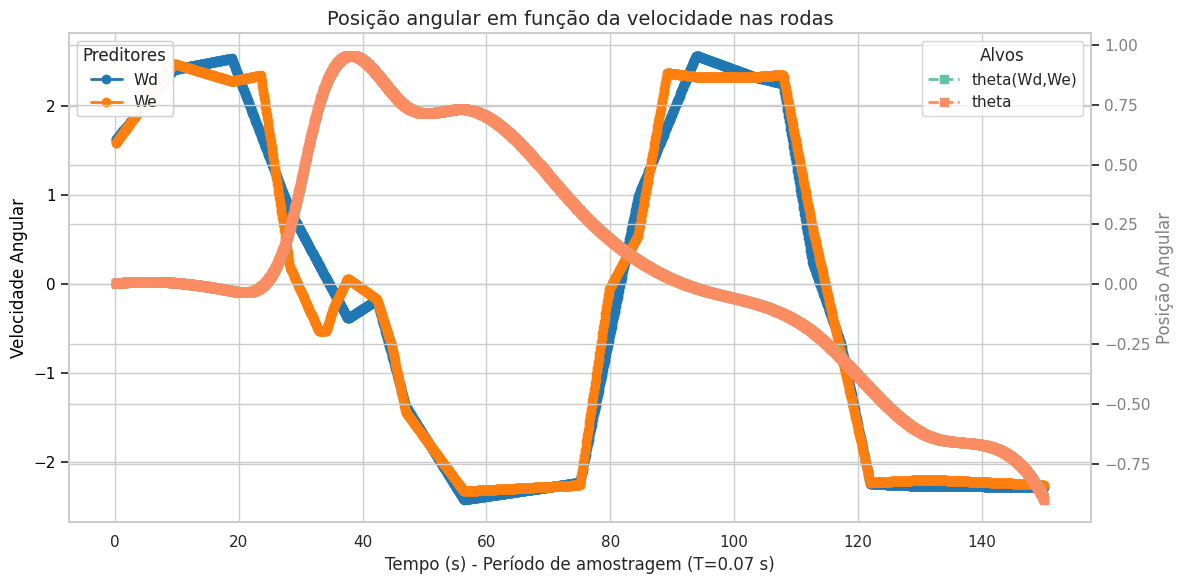

In [32]:
PlotTimeSeries(data)

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pykrige.ok3d import OrdinaryKriging3D
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

PREDICTORS = ["Wd", "We", "theta"]
TARGET = "theta(Wd,We)"

VARIOGRAMS = ["gaussian", "spherical", "exponential", "power", "linear", "hole-effect"]

class Kriging3D:
    
    def __init__(self, Dataset):
        # Separação dos dados em treino/teste
        train_data, test_data = train_test_split(Dataset, test_size=0.25, shuffle=False)

        # Padronizadores
        self.x_scaler = StandardScaler().fit(train_data[PREDICTORS])
        self.y_scaler = StandardScaler().fit(train_data[[TARGET]])

        # Normalizando os dados
        self.train_samples_x = self.x_scaler.transform(train_data[PREDICTORS])
        self.train_samples_y = self.y_scaler.transform(train_data[[TARGET]]).ravel()
        
        self.test_samples_x = self.x_scaler.transform(test_data[PREDICTORS])
        self.test_samples_y = self.y_scaler.transform(test_data[[TARGET]]).ravel()
        
        # Armazenar tempos para plotagem
        self.train_time = train_data.index
        self.test_time = test_data.index

        self.kriging_model = None

    def BuildModel(self, VariogramType):
        self.kriging_model = OrdinaryKriging3D(
            self.train_samples_x[:, 0],
            self.train_samples_x[:, 1],
            self.train_samples_x[:, 2],
            self.train_samples_y,
            variogram_model=VariogramType
        )
    
    def ComputeMetrics(self):
        # Previsões em pontos
        train_pred = self.kriging_model.execute(
            'points',
            self.train_samples_x[:, 0],
            self.train_samples_x[:, 1],
            self.train_samples_x[:, 2]
        )[0]

        test_pred = self.kriging_model.execute(
            'points',
            self.test_samples_x[:, 0],
            self.test_samples_x[:, 1],
            self.test_samples_x[:, 2]
        )[0]

        # Desnormalização
        self.train_pred = self.y_scaler.inverse_transform(train_pred.reshape(-1, 1)).ravel()
        self.test_pred = self.y_scaler.inverse_transform(test_pred.reshape(-1, 1)).ravel()
        train_y_orig = self.y_scaler.inverse_transform(self.train_samples_y.reshape(-1, 1)).ravel()
        test_y_orig = self.y_scaler.inverse_transform(self.test_samples_y.reshape(-1, 1)).ravel()

        # Métricas
        return {
            'r2_training': r2_score(train_y_orig, self.train_pred),
            'mse_training': mean_squared_error(train_y_orig, self.train_pred),
            'mape_training': mean_absolute_percentage_error(train_y_orig, self.train_pred),
            'rmse_training': root_mean_squared_error(train_y_orig, self.train_pred),

            'r2_test': r2_score(test_y_orig, self.test_pred),
            'mse_test': mean_squared_error(test_y_orig, self.test_pred),
            'mape_test': mean_absolute_percentage_error(test_y_orig, self.test_pred),
            'rmse_test': root_mean_squared_error(test_y_orig, self.test_pred),
        }

    def PlotOut(self, variogram):
        colors = plt.cm.tab10.colors
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        ax1.plot(self.train_time, self.train_pred, marker="o", label="train_pred", color=colors[0])
        ax1.plot(self.train_time, self.y_scaler.inverse_transform(self.train_samples_y.reshape(-1, 1)).ravel(),
                 marker="o", label="train_orig", color=colors[1])
        ax1.set_title("Dados de Treinamento")
        ax1.set_xlabel("Tempo (s)")
        ax1.set_ylabel("Velocidade Angular")
        ax1.legend()
        ax1.grid(True)

        ax2.plot(self.test_time, self.test_pred, marker="o", label="test_pred", color=colors[2])
        ax2.plot(self.test_time, self.y_scaler.inverse_transform(self.test_samples_y.reshape(-1, 1)).ravel(),
                 marker="o", label="test_orig", color=colors[3])
        ax2.set_title("Dados de Teste")
        ax2.set_xlabel("Tempo (s)")
        ax2.legend()
        ax2.grid(True)

        fig.suptitle(f"Resultados do modelo Kriging 3D: {variogram}")
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(f"content/figs/{variogram}.svg", format="svg", dpi=600)
        plt.show()

    def EvalModel(self, excel_path):
        self.models = {}
        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            for variogram in VARIOGRAMS:
                self.BuildModel(VariogramType=variogram)
                metrics = self.ComputeMetrics()
                self.models[variogram] = self.kriging_model

                display(metrics)
                df = pd.DataFrame([metrics])
                df.to_excel(writer, sheet_name=variogram, index=False)
                self.PlotOut(variogram)



{'r2_training': -77760.03073540756,
 'mse_training': 9910.150855704427,
 'mape_training': 3809.997029413696,
 'rmse_training': 99.54974061093493,
 'r2_test': -6403522001499.759,
 'mse_test': 194627148887.11032,
 'mape_test': 580703.1373720907,
 'rmse_test': 441165.6705673168}

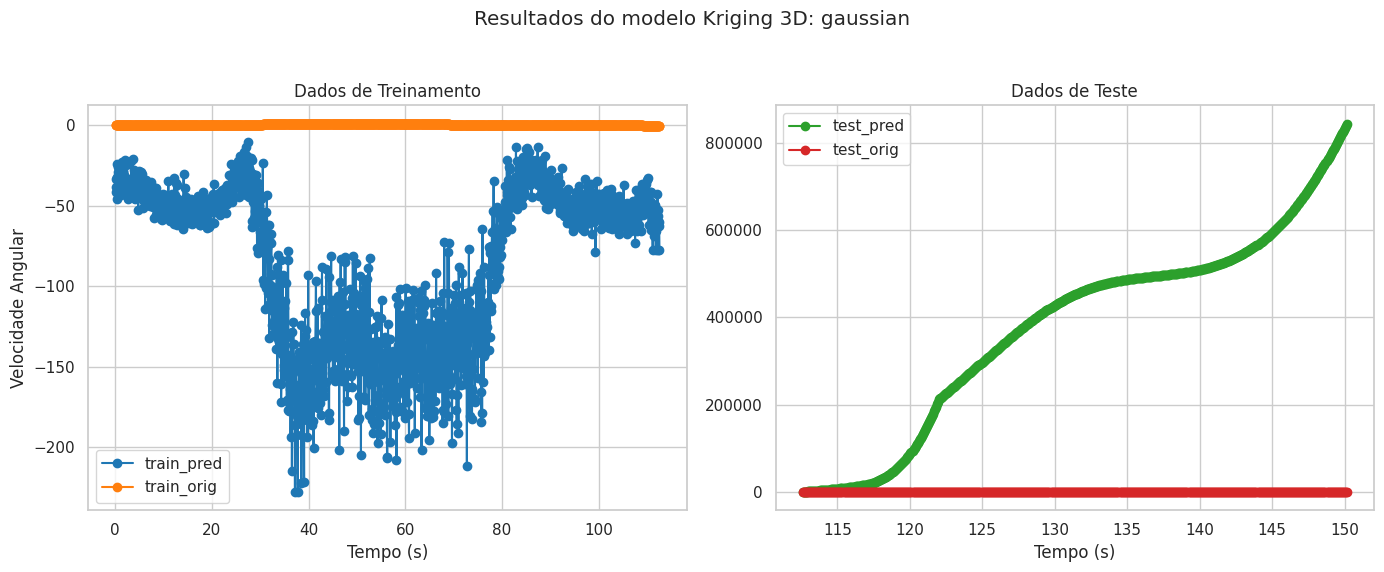

{'r2_training': 1.0,
 'mse_training': 1.0136849058159708e-24,
 'mape_training': 2.29657785575986e-11,
 'rmse_training': 1.0068192021490109e-12,
 'r2_test': -19.15870635892218,
 'mse_test': 0.6126990026691517,
 'mape_test': 1.2202109558021883,
 'rmse_test': 0.7827509199414279}

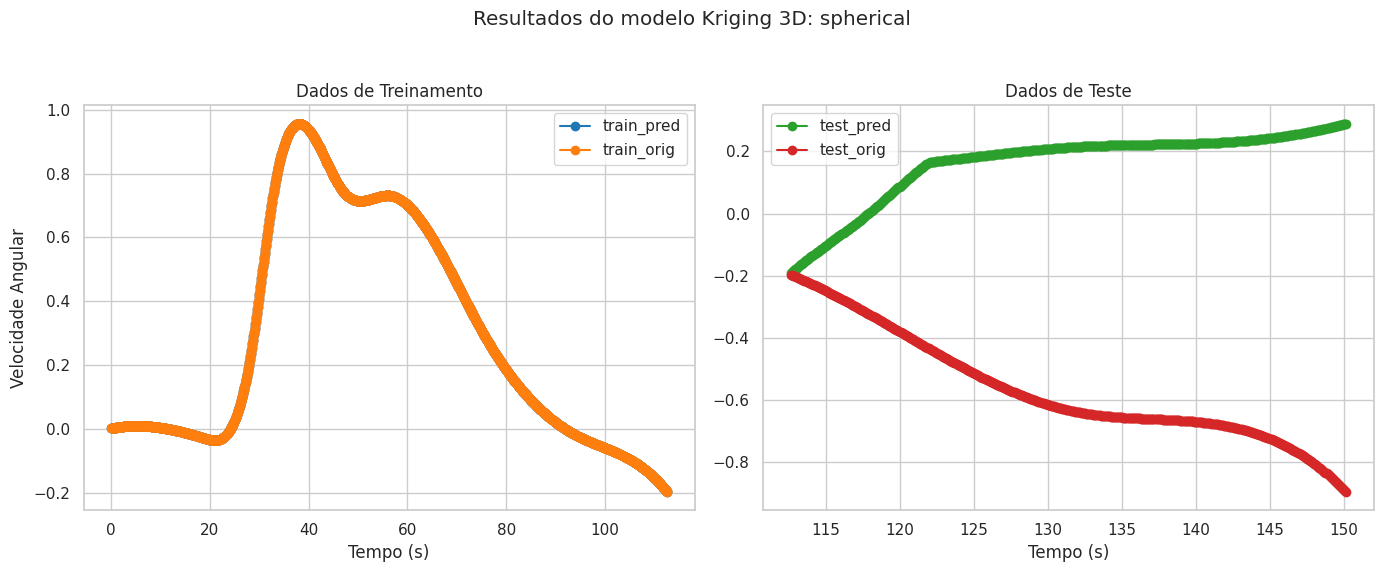

{'r2_training': 1.0,
 'mse_training': 2.9194572652750704e-25,
 'mape_training': 3.550178503307458e-11,
 'rmse_training': 5.40320022327053e-13,
 'r2_test': -20.80721559576885,
 'mse_test': 0.6628034065591264,
 'mape_test': 1.3234905875028729,
 'rmse_test': 0.8141273896382104}

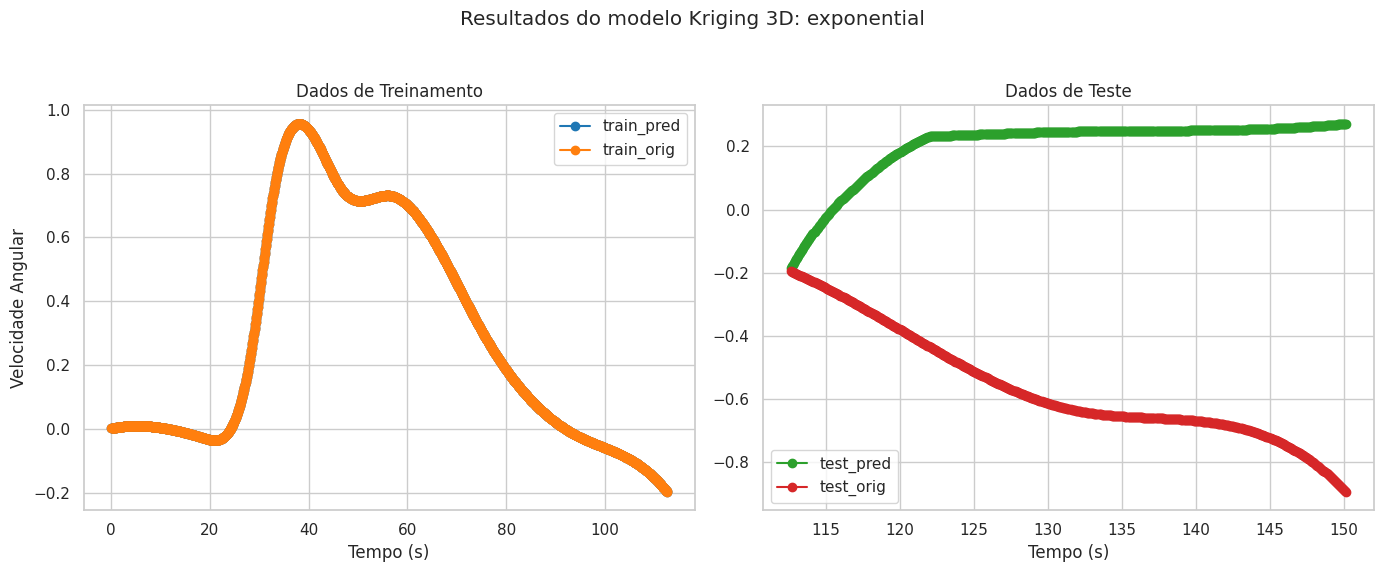

{'r2_training': 1.0,
 'mse_training': 3.3782148859679476e-22,
 'mape_training': 1.1744777248587094e-09,
 'rmse_training': 1.8379920799524538e-11,
 'r2_test': -2.826267970548727,
 'mse_test': 0.11629469310973527,
 'mape_test': 0.524534101573989,
 'rmse_test': 0.3410200772824604}

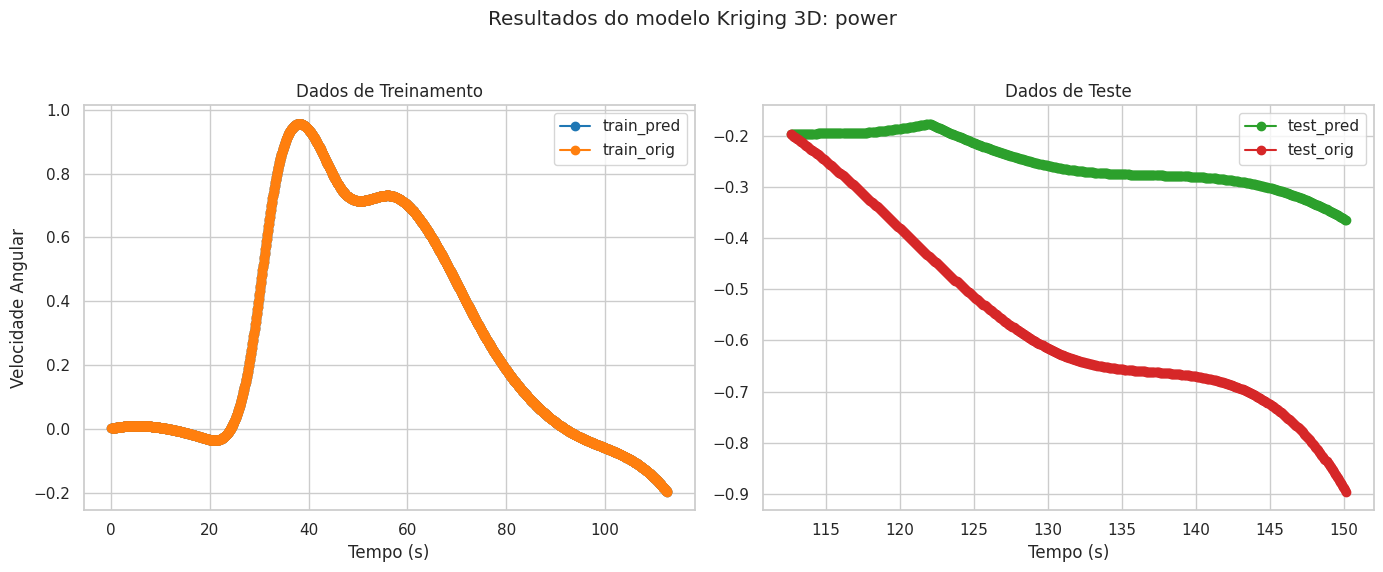

{'r2_training': 1.0,
 'mse_training': 1.1414931078244443e-24,
 'mape_training': 6.122106977049303e-11,
 'rmse_training': 1.0684068082076435e-12,
 'r2_test': -7.0345728624225945,
 'mse_test': 0.2442009269855826,
 'mape_test': 0.7760733592507627,
 'rmse_test': 0.4941669019527538}

Exception ignored in: <function ZipFile.__del__ at 0x705f37c9f380>
Traceback (most recent call last):
  File "/usr/local/python/3.12.1/lib/python3.12/zipfile/__init__.py", line 1917, in __del__
    self.close()
  File "/usr/local/python/3.12.1/lib/python3.12/zipfile/__init__.py", line 1934, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


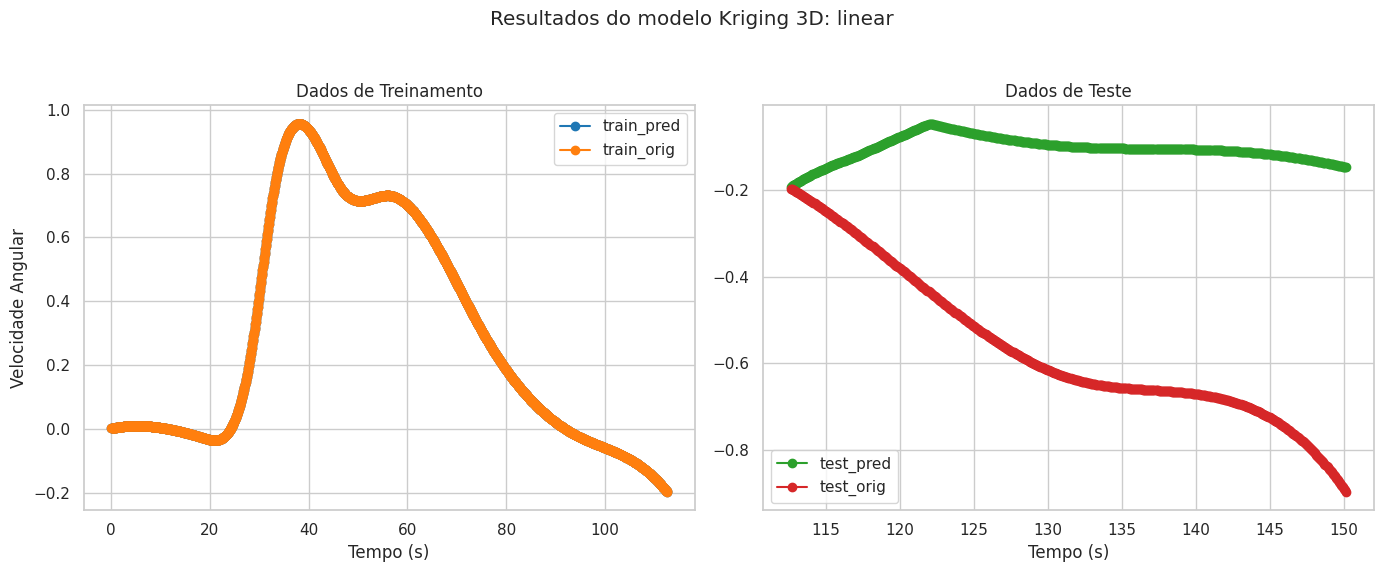

{'r2_training': 1.0,
 'mse_training': 2.3380377320997477e-25,
 'mape_training': 2.7722005657091457e-11,
 'rmse_training': 4.835325978773042e-13,
 'r2_test': -28.34528638580174,
 'mse_test': 0.8919137657691781,
 'mape_test': 1.5856731409329305,
 'rmse_test': 0.9444118623615325}

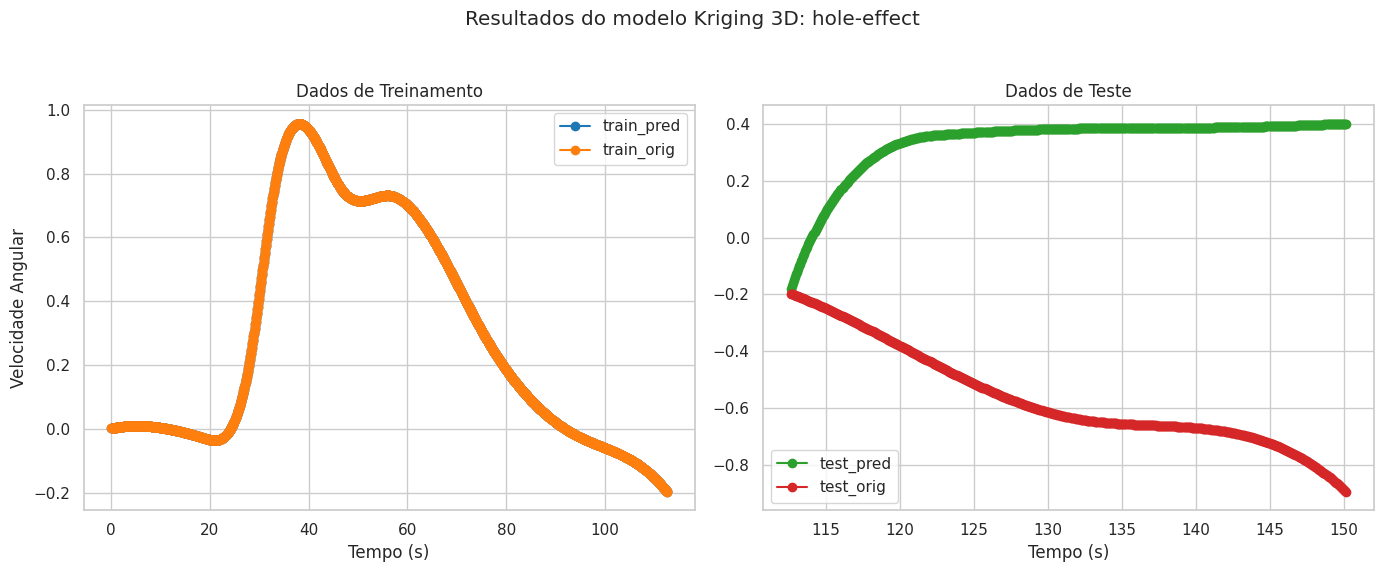

In [34]:
Vsg = Kriging3D(Dataset=data)        
Vsg.EvalModel("./content/KrigingMetrics.xlsx")